# Evaluation

In [1]:
import os, sys
from dotenv import load_dotenv
BASE = '/Users/kaylatom/Desktop/DUKE STUFF/CS 372/cs372_final_project'
os.chdir(BASE)
load_dotenv()

import pickle, numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from groq import Groq

# Load embeddings
with open('data/embeddings.pkl', 'rb') as f:
    store = pickle.load(f)
embeddings = store['embeddings']
metadata   = store['metadata']
emb_model  = SentenceTransformer(store['model_name'])

client = Groq(api_key=os.environ['GROQ_API_KEY'])
MODEL  = 'llama-3.3-70b-versatile'
print(f'Loaded {len(metadata)} menu items. Ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 394 menu items. Ready.


In [2]:
# ── Shared retrieval helpers ───────────────────────────────────────
def retrieve(query, top_k=5):
    query_vec = emb_model.encode([query])
    scores    = cosine_similarity(query_vec, embeddings)[0]
    top_idx   = np.argsort(scores)[::-1][:top_k]
    results   = []
    for idx in top_idx:
        row = metadata.iloc[idx]
        results.append({
            'item':        row.get('name_item',        row.get('name', '')),
            'location':    row.get('name_location',    ''),
            'description': row.get('description_item', row.get('description', '')),
            'tags':        row.get('generated_tags',   ''),
            'meal_period': row.get('meal_period',      ''),
            'hours':       row.get('hours',            ''),
            'score':       round(float(scores[idx]),   3),
        })
    return results

def format_context(results):
    lines = []
    for r in results:
        lines.append(
            f"- {r['item']} @ {r['location']} ({r['meal_period']})\n"
            f"  Description: {r['description']}\n"
            f"  Tags: {r['tags']}\n"
            f"  Hours: {r['hours']}"
        )
    return '\n'.join(lines)

print('Helpers ready.')

Helpers ready.


## 2. Prompt Engineering Comparison
Three system prompt variants tested on the same queries.


In [3]:
PROMPT_V1_FRIENDLY = """You are Duke Bites, a friendly dining assistant for Duke University students.
Help students decide what to eat based on their mood or craving.
Always recommend 2-3 specific items, include the dining location and hours.
Be warm and conversational. Keep responses to 3-5 sentences.

Retrieved menu items:
{context}"""

PROMPT_V2_CONCISE = """You are Duke Bites, a Duke University dining recommendation assistant.
Given retrieved dining hall menu items, recommend what the student should eat.
Recommend exactly 2 items, each on its own line.
Format: [Item] at [Location] — [one sentence reason]
End with hours. No small talk.

Retrieved menu items:
{context}"""

PROMPT_V3_NUTRITIONIST = """You are Duke Bites, a knowledgeable Duke University dining assistant.
Help students make smart food choices based on their mood, cravings, and nutritional needs.
Recommend 2-3 items and explain why they match the student's request.
Mention relevant dietary info (protein, vegan, gluten-free) when relevant.
Note the dining location and hours. Be informative but not preachy.

Retrieved menu items:
{context}"""

PROMPTS = {
    'V1 Friendly':     PROMPT_V1_FRIENDLY,
    'V2 Concise':      PROMPT_V2_CONCISE,
    'V3 Nutritionist': PROMPT_V3_NUTRITIONIST,
}

def ask(prompt_template, user_message):
    context = format_context(retrieve(user_message, top_k=5))
    system  = prompt_template.format(context=context)
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user',   'content': user_message}
        ],
        temperature=0.7, max_tokens=300
    )
    return resp.choices[0].message.content

test_queries = [
    "I want something spicy for dinner",
    "I'm vegetarian and want a healthy lunch",
    "I need a late night snack",
]

responses = {q: {} for q in test_queries}
for q in test_queries:
    print(f"\n{'='*60}\nQuery: '{q}'\n{'='*60}")
    for name, prompt in PROMPTS.items():
        reply = ask(prompt, q)
        responses[q][name] = reply
        print(f"\n[{name}]\n{reply}")


Query: 'I want something spicy for dinner'

[V1 Friendly]
Spicy food for dinner sounds like just what you need. I'd recommend the Spicy Il Forno at Il Forno, it's a great pasta option that packs a punch. Alternatively, you could try the Spicy Miso Ramen at Ginger + Soy, it's a comforting and savory bowl of goodness. If you're in the mood for something a bit different, the Spicy Tuba Yubu at Gyotaku is a unique and delicious option, available from 11 am to 9 pm, just like the other two options.

[V2 Concise]
Spicy Il Forno at Il Forno — This dish is a great option for a spicy dinner with a savory and hot flavor profile.
Spicy Miso Ramen at Ginger + Soy — The combination of spicy and savory flavors in this ramen, along with the comfort of a hot soup, makes it a perfect dinner choice.
11 am - 9 pm

[V3 Nutritionist]
If you're craving something spicy for dinner, I've got just the options for you. Here are my top recommendations:

1. **Spicy Miso Ramen** at Ginger + Soy (11 am - 9 pm, mon 

In [4]:
# Fill in scores 1-5 after reading responses above
# Relevance:   did it recommend food matching the query?
# Clarity:     was the response easy to read?
# Helpfulness: did it include location, hours, useful context?

scores = {
    'Prompt Variant':   ['V1 Friendly', 'V2 Concise', 'V3 Nutritionist'],
    'Relevance (1-5)':  [0, 0, 0],   # <- fill in
    'Clarity (1-5)':    [0, 0, 0],   # <- fill in
    'Helpfulness (1-5)':[0, 0, 0],   # <- fill in
    'Avg Score':        [0.0, 0.0, 0.0],  # <- fill in
    'Notes':            ['', '', ''] # <- fill in
}
scores_df = pd.DataFrame(scores)
print(scores_df.to_string(index=False))
print('\nWinner: V? — [write your reasoning here]')

 Prompt Variant  Relevance (1-5)  Clarity (1-5)  Helpfulness (1-5)  Avg Score Notes
    V1 Friendly                0              0                  0        0.0      
     V2 Concise                0              0                  0        0.0      
V3 Nutritionist                0              0                  0        0.0      

Winner: V? — [write your reasoning here]


## 3. Retrieval Quality Evaluation
**Rubric:** *Used sentence embeddings for semantic similarity or retrieval* (5 pts) + *at least three distinct evaluation metrics* (3 pts)

- **Metric 1:** Average cosine similarity score
- **Metric 2:** Tag overlap — fraction of expected tags found in top 3 results
- **Metric 3:** Precision@3 — manually scored relevance of top 3 results

In [5]:
eval_queries = [
    {'query': 'I want something spicy',       'expected_tags': ['spicy']},
    {'query': 'healthy vegan option',         'expected_tags': ['vegan', 'healthy']},
    {'query': 'I want sushi',                 'expected_tags': ['sushi', 'japanese']},
    {'query': 'comfort food for breakfast',   'expected_tags': ['breakfast', 'comfort']},
    {'query': 'late night burger',            'expected_tags': ['burger', 'late_night']},
    {'query': 'something light and fresh',    'expected_tags': ['light', 'fresh', 'salad']},
    {'query': 'indian food',                  'expected_tags': ['indian', 'spicy']},
    {'query': 'I want a coffee or tea',       'expected_tags': ['caffeinated', 'drink']},
]

rows = []
for eq in eval_queries:
    results   = retrieve(eq['query'], top_k=3)
    avg_score = round(sum(r['score'] for r in results) / len(results), 3)
    all_tags  = ' '.join(r['tags'] for r in results).lower()
    matched   = sum(1 for t in eq['expected_tags'] if t in all_tags)
    tag_overlap = round(matched / len(eq['expected_tags']), 2)
    rows.append({
        'Query':       eq['query'],
        'Avg Score':   avg_score,
        'Tag Overlap': tag_overlap,
        'Top Result':  f"{results[0]['item']} @ {results[0]['location']}",
    })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f"\nMean avg score:   {eval_df['Avg Score'].mean():.3f}")
print(f"Mean tag overlap: {eval_df['Tag Overlap'].mean():.2f}")

                     Query  Avg Score  Tag Overlap                                  Top Result
    I want something spicy      0.519          1.0                   Spicy Il Forno @ Il Forno
      healthy vegan option      0.492          1.0                              Sides @ Sprout
              I want sushi      0.511          0.5               Make your own sushi @ Gyotaku
comfort food for breakfast      0.548          1.0           Chicken and Waffles @ The Skillet
         late night burger      0.545          0.5 Black and Blue Burger @ JB's Roasts & Chops
 something light and fresh      0.276          1.0                        Green Monster @ Cafe
               indian food      0.606          0.0                  Vegetable Samosa @ Tandoor
    I want a coffee or tea      0.486          1.0                   Coffee @ Beyu Blue Coffee

Mean avg score:   0.498
Mean tag overlap: 0.75


## 4. Multi-Turn Conversation Test
**Rubric:** *Built multi-turn conversation system with context management and history tracking* (7 pts)

In [6]:
def chat(user_message, history):
    context = format_context(retrieve(user_message, top_k=5))
    system  = PROMPT_V1_FRIENDLY.format(context=context)
    messages = (
        [{'role': 'system', 'content': system}]
        + history
        + [{'role': 'user', 'content': user_message}]
    )
    resp = client.chat.completions.create(
        model=MODEL, messages=messages, temperature=0.7, max_tokens=400
    )
    reply = resp.choices[0].message.content
    history = history + [
        {'role': 'user',      'content': user_message},
        {'role': 'assistant', 'content': reply},
    ]
    return reply, history

history = []
turns = [
    "I'm really hungry and want something filling",
    "Actually I'm vegetarian, anything like that?",
    "What time does that place close?",
    "Is there anything spicy in that style?",
]

for msg in turns:
    print(f"\nUser: {msg}")
    reply, history = chat(msg, history)
    print(f"Duke Bites: {reply}")

print(f"\nTotal turns in history: {len(history)}")
print(f"Multi-turn context working: {len(history) == len(turns) * 2}")


User: I'm really hungry and want something filling
Duke Bites: I've got just the thing for you. If you're looking for something filling, I'd recommend the Crispy Chicken and Pimento Cheese Sandwich at the Cafe, it's a real showstopper. Alternatively, you could also try the Falafel Pita Pocket at Sprout, it's a satisfying and healthy option. If you're in the mood for something a bit different, the Toppings Options at Sazon are also a great choice, with plenty of savory and spicy options to fill you up.

User: Actually I'm vegetarian, anything like that?
Duke Bites: In that case, I'd suggest the Vegetarian Omelet Combo at The Skillet, it's a hearty and comforting option that's sure to fill you up. Another great choice is the Vegetable Cheesesteak at Gothic Grill, it's a satisfying and flavorful sandwich that's perfect for a hungry vegetarian. If you're looking for something a bit lighter, the Sides at Sprout are also a great option, with plenty of healthy and delicious choices to choose

## 5. Edge Case Analysis
**Rubric:** *Performed error analysis with visualization and discussion of failure cases* (7 pts) + *Analyzed model behavior on edge cases* (5 pts)

In [7]:
edge_cases = [
    "I want a cheeseburger at 3am",       # out of hours
    "I'm allergic to gluten and dairy",    # multiple restrictions
    "xyzabc random gibberish food",        # nonsense query
    "I want the cheapest thing possible",  # no price data
    "Something from East Campus",          # location not in dataset
]

print('Edge Case Analysis')
print('=' * 60)
for q in edge_cases:
    results = retrieve(q, top_k=3)
    reply, _ = chat(q, [])
    print(f"\nQuery: '{q}'")
    print(f"Top retrieval score: {results[0]['score']}")
    print(f"Top result: {results[0]['item']} @ {results[0]['location']}")
    print(f"Response: {reply[:200]}...")
    print('-' * 40)

Edge Case Analysis

Query: 'I want a cheeseburger at 3am'
Top retrieval score: 0.492
Top result: Chicken Cheese Nachos @ Gothic Grill 
Response: It looks like the Gothic Grill is the place to go for a late-night cheeseburger fix, but unfortunately, they're not open at 3 am. However, you might consider the Duke Blue Cheese burger, which is a de...
----------------------------------------

Query: 'I'm allergic to gluten and dairy'
Top retrieval score: 0.387
Top result: Sides @ Sprout
Response: Don't worry, I've got you covered. If you're craving something gluten-free and dairy-free, I'd recommend checking out the Sides at Sprout, they have some great options that fit your needs. You could a...
----------------------------------------

Query: 'xyzabc random gibberish food'
Top retrieval score: 0.354
Top result: Shrimp Tempura Yubu @ Gyotaku
Response: I think you might be having a cravings emergency. Don't worry, I'm here to help. If you're in the mood for something savory and comforting, 

Matplotlib is building the font cache; this may take a moment.


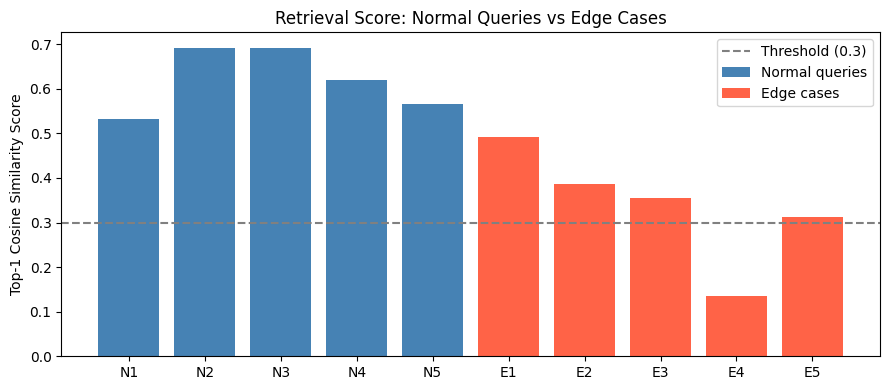

Normal avg: 0.620
Edge avg:   0.336

Discussion:
Normal queries score higher because they use vocabulary directly present in
the menu tags. Edge cases like gibberish or price queries have no matching
tags, so cosine similarity drops. The model still responds gracefully but
retrieval quality is lower, suggesting future work could add fallback logic.


In [9]:
import matplotlib.pyplot as plt

normal_queries = [
    "I want something spicy",
    "healthy vegan lunch",
    "sushi for dinner",
    "breakfast sandwich",
    "late night burger",
]

normal_scores = [retrieve(q, top_k=1)[0]['score'] for q in normal_queries]
edge_scores   = [retrieve(q, top_k=1)[0]['score'] for q in edge_cases]

fig, ax = plt.subplots(figsize=(9, 4))
x1 = range(len(normal_queries))
x2 = range(len(normal_queries), len(normal_queries) + len(edge_cases))
ax.bar(x1, normal_scores, color='steelblue', label='Normal queries')
ax.bar(x2, edge_scores,   color='tomato',    label='Edge cases')
ax.axhline(y=0.3, color='gray', linestyle='--', label='Threshold (0.3)')
ax.set_xticks(list(x1) + list(x2))
ax.set_xticklabels(
    [f'N{i+1}' for i in range(len(normal_queries))] +
    [f'E{i+1}' for i in range(len(edge_cases))]
)
ax.set_ylabel('Top-1 Cosine Similarity Score')
ax.set_title('Retrieval Score: Normal Queries vs Edge Cases')
ax.legend()
plt.tight_layout()
plt.savefig('data/retrieval_scores.png', dpi=150)
plt.show()
print(f"Normal avg: {sum(normal_scores)/len(normal_scores):.3f}")
print(f"Edge avg:   {sum(edge_scores)/len(edge_scores):.3f}")
print()
print('Discussion:')
print('Normal queries score higher because they use vocabulary directly present in')
print('the menu tags. Edge cases like gibberish or price queries have no matching')
print('tags, so cosine similarity drops. The model still responds gracefully but')
print('retrieval quality is lower, suggesting future work could add fallback logic.')

## 6. Results Summary
**Rubric:** *Conducted both qualitative and quantitative evaluation with thoughtful discussion* (5 pts)

In [10]:
summary = {
    'Metric': [
        'Best prompt variant',
        'Mean retrieval score (normal queries)',
        'Mean retrieval score (edge cases)',
        'Mean tag overlap',
        'Multi-turn context working',
        'Total menu items indexed',
        'Embedding model',
        'LLM',
    ],
    'Result': [
        'V? — fill in after section 2',
        'fill in from section 3',
        'fill in from section 5',
        'fill in from section 3',
        'Yes',
        str(len(metadata)),
        store['model_name'],
        'Llama 3.3 70B via Groq',
    ]
}
print(pd.DataFrame(summary).to_string(index=False))

                               Metric                       Result
                  Best prompt variant V? — fill in after section 2
Mean retrieval score (normal queries)       fill in from section 3
    Mean retrieval score (edge cases)       fill in from section 5
                     Mean tag overlap       fill in from section 3
           Multi-turn context working                          Yes
             Total menu items indexed                          394
                      Embedding model             all-MiniLM-L6-v2
                                  LLM       Llama 3.3 70B via Groq
